# Lab Assignment 5 — Feature Selection Algorithms

Dataset: Pima Indians Diabetes (`pima-indians-diabetes.csv`)

We implement four feature selection techniques — univariate selection (chi-squared), Recursive Feature Elimination, L1-based selection, and tree-based (Random Forest) selection — and compare how each affects classification accuracy against using all features.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, chi2, RFE, SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

## Loading the data

In [2]:
cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
df = pd.read_csv('pima-indians-diabetes.csv', names=cols)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.shape

(768, 9)

In [4]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

## Train/test split

In [5]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Baseline model — all 8 features

Random Forest is used as the evaluation model throughout so the comparison across feature selection methods is fair.

In [6]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train_scaled, y_train)
baseline_acc = accuracy_score(y_test, rf.predict(X_test_scaled))
baseline_acc

0.7467532467532467

## 1. Univariate feature selection — SelectKBest (chi-squared)

All raw feature values in this dataset are non-negative, so chi2 can be applied directly without scaling.

In [7]:
selector_chi2 = SelectKBest(score_func=chi2, k=5)
selector_chi2.fit(X_train, y_train)
chi2_features = X.columns[selector_chi2.get_support()]
chi2_features

Index(['Pregnancies', 'Glucose', 'Insulin', 'BMI', 'Age'], dtype='str')

In [8]:
X_train_chi2 = scaler.fit_transform(X_train[chi2_features])
X_test_chi2 = scaler.transform(X_test[chi2_features])

rf_chi2 = RandomForestClassifier(n_estimators=200, random_state=42)
rf_chi2.fit(X_train_chi2, y_train)
chi2_acc = accuracy_score(y_test, rf_chi2.predict(X_test_chi2))
chi2_acc

0.7272727272727273

## 2. Recursive Feature Elimination (RFE)

In [9]:
rfe = RFE(estimator=LogisticRegression(max_iter=1000), n_features_to_select=5)
rfe.fit(X_train_scaled, y_train)
rfe_features = X.columns[rfe.support_]
rfe_features

Index(['Pregnancies', 'Glucose', 'BMI', 'DiabetesPedigreeFunction', 'Age'], dtype='str')

In [10]:
X_train_rfe = X_train_scaled[:, rfe.support_]
X_test_rfe = X_test_scaled[:, rfe.support_]

rf_rfe = RandomForestClassifier(n_estimators=200, random_state=42)
rf_rfe.fit(X_train_rfe, y_train)
rfe_acc = accuracy_score(y_test, rf_rfe.predict(X_test_rfe))
rfe_acc

0.7662337662337663

## 3. L1-based feature selection (L1-penalized logistic regression)

In [11]:
l1_model = LogisticRegression(penalty='l1', solver='liblinear', C=0.05, random_state=42)
l1_model.fit(X_train_scaled, y_train)

l1_selector = SelectFromModel(l1_model, prefit=True)
l1_features = X.columns[l1_selector.get_support()]
l1_features

Index(['Pregnancies', 'Glucose', 'BMI', 'DiabetesPedigreeFunction', 'Age'], dtype='str')

In [12]:
X_train_l1 = l1_selector.transform(X_train_scaled)
X_test_l1 = l1_selector.transform(X_test_scaled)

rf_l1 = RandomForestClassifier(n_estimators=200, random_state=42)
rf_l1.fit(X_train_l1, y_train)
l1_acc = accuracy_score(y_test, rf_l1.predict(X_test_l1))
l1_acc

0.7662337662337663

## 4. Tree-based feature selection (Random Forest importance)

In [13]:
rf_importance = RandomForestClassifier(n_estimators=200, random_state=42)
rf_importance.fit(X_train_scaled, y_train)
importances = pd.Series(rf_importance.feature_importances_, index=X.columns).sort_values(ascending=False)
importances

Glucose                     0.266073
BMI                         0.161420
Age                         0.130861
DiabetesPedigreeFunction    0.127089
BloodPressure               0.086335
Pregnancies                 0.084277
Insulin                     0.073752
SkinThickness               0.070194
dtype: float64

In [14]:
tree_features = importances.head(5).index

X_train_tree = scaler.fit_transform(X_train[tree_features])
X_test_tree = scaler.transform(X_test[tree_features])

rf_tree = RandomForestClassifier(n_estimators=200, random_state=42)
rf_tree.fit(X_train_tree, y_train)
tree_acc = accuracy_score(y_test, rf_tree.predict(X_test_tree))
tree_acc

0.7727272727272727

## Which features did each method keep?

In [15]:
selected = pd.DataFrame({
    'chi2': pd.Series(list(chi2_features)),
    'RFE': pd.Series(list(rfe_features)),
    'L1': pd.Series(list(l1_features)),
    'Tree-based': pd.Series(list(tree_features))
})
selected

,chi2,RFE,L1,Tree-based
0,Pregnancies,Pregnancies,Pregnancies,Glucose
1,Glucose,Glucose,Glucose,BMI
2,Insulin,BMI,BMI,Age
3,BMI,DiabetesPedigreeFunction,DiabetesPedigreeFunction,DiabetesPedigreeFunction
4,Age,Age,Age,BloodPressure


## Comparing accuracy across methods

In [16]:
results = pd.DataFrame({
    'Method': ['All features', 'SelectKBest (chi2)', 'RFE', 'L1 (Lasso)', 'Tree-based (RF)'],
    'Num Features': [X.shape[1], len(chi2_features), len(rfe_features), len(l1_features), len(tree_features)],
    'Accuracy': [baseline_acc, chi2_acc, rfe_acc, l1_acc, tree_acc]
})
results

,Method,Num Features,Accuracy
0,All features,8,0.746753
1,SelectKBest (chi2),5,0.727273
2,RFE,5,0.766234
3,L1 (Lasso),5,0.766234
4,Tree-based (RF),5,0.772727


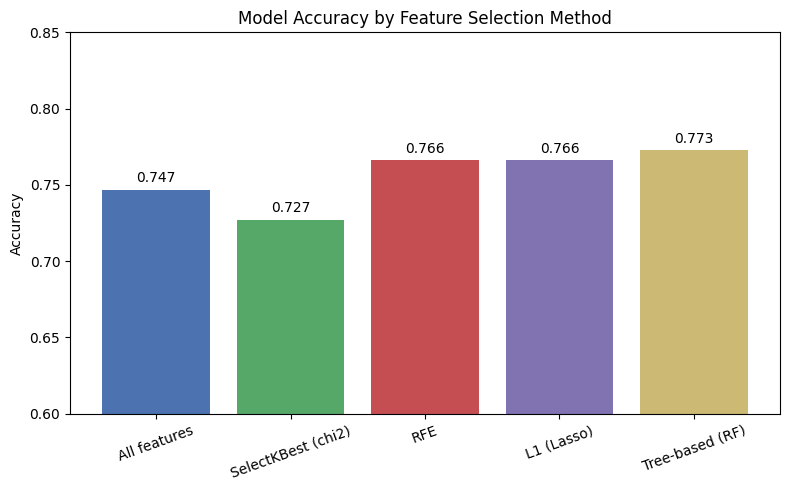

In [17]:
plt.figure(figsize=(8, 5))
bars = plt.bar(results['Method'], results['Accuracy'], color=['#4c72b0', '#55a868', '#c44e52', '#8172b2', '#ccb974'])
plt.ylabel('Accuracy')
plt.title('Model Accuracy by Feature Selection Method')
plt.ylim(0.6, 0.85)
plt.xticks(rotation=20)
for bar, acc in zip(bars, results['Accuracy']):
    plt.text(bar.get_x() + bar.get_width() / 2, acc + 0.005, f'{acc:.3f}', ha='center')
plt.tight_layout()
plt.show()

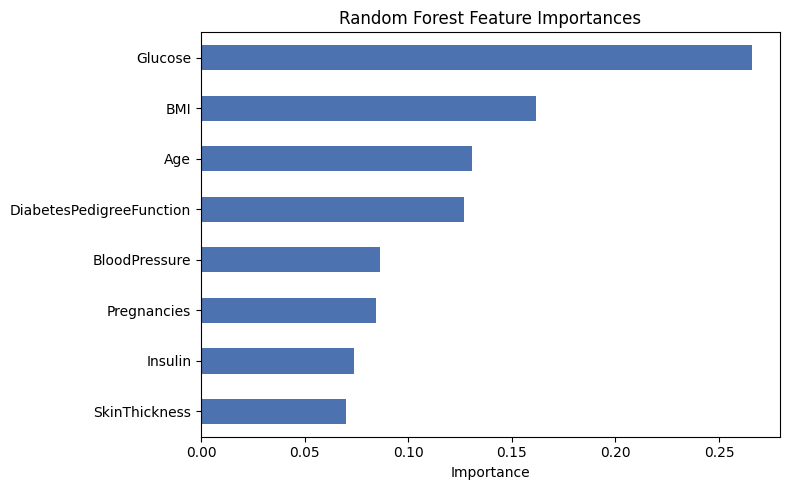

In [18]:
plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='#4c72b0')
plt.xlabel('Importance')
plt.title('Random Forest Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Observations

Every feature selection method except chi2 matched or beat the 8-feature baseline (74.7%) while using 5 features instead of 8. Tree-based selection with the Random Forest came out on top at 77.3%, followed by RFE and L1 tied at 76.6%. SelectKBest with chi2 was the weakest at 72.7%, likely because it dropped BloodPressure and DiabetesPedigreeFunction in favor of Insulin, which the tree-based importances rank as one of the least useful features in this dataset.

Glucose, BMI and Age show up in the top 5 for every method, which lines up with what is generally known about diabetes risk factors, so the feature selection results look sensible rather than arbitrary. Overall, cutting the feature count from 8 to 5 did not hurt accuracy and in three of four cases improved it, which is the main point of doing feature selection in the first place.